## Wine Quality Prediction

### OIBSIP Data Analytics — Level 2 — Task 2

### Objective

The objective of this project is to build and compare multiple machine learning classification models to predict wine quality based on its physicochemical properties.

The models used are:

- Random Forest Classifier
- SGD Classifier
- Support Vector Classifier (SVC)

The original wine quality scores will be transformed into three categories:

- Low Quality
- Medium Quality
- High Quality

The models will be evaluated using accuracy, classification reports, and
confusion matrices. Random Forest feature importance will also be analyzed.

### Tech stack: 
Python, pandas, numpy, scikit-learn (Random Forest, SGD, SVC), seaborn, matplotlib, Jupyter Notebook

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

### Load Dataset

In [ ]:
df = pd.read_csv("winequality-red.csv", sep=";")

### Dataset Description

The Wine Quality dataset contains physicochemical measurements of wines together with their quality scores.

The dataset includes 11 chemical features:

- Fixed acidity
- Volatile acidity
- Citric acid
- Residual sugar
- Chlorides
- Free sulfur dioxide
- Total sulfur dioxide
- Density
- pH
- Sulphates
- Alcohol

The original `quality` variable represents the wine quality score on a scale from 3 to 8.

For this classification task, the quality scores are transformed into three broader quality categories.

### Initial Dataset Inspection

In [ ]:
print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (1599, 12)

First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



Column Names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality         

### Dataset Structure

The dataset contains 1,599 observations and 12 columns.

There are 11 physicochemical features and one target variable, `quality`.

All variables are numerical, so no categorical encoding is required for the original features.

The numerical nature of the dataset makes it suitable for the selected machine learning algorithms.

In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### Statistical Summary

The descriptive statistics show that the physicochemical variables have different ranges and distributions.

For example, alcohol, density, acidity, and sulfur dioxide have considerably different numerical scales.

These differences in scale are particularly important for distance- and gradient-based algorithms such as SVC and SGD. Therefore, feature standardization will be applied before training these models.

### Missing Value Analysis

The dataset was checked for missing values across all columns.

No missing values were found, so no imputation or missing-value treatment was necessary.

This allows the dataset to proceed directly to exploratory analysis and model preparation.

In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


### Duplicate Values

In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 240


In [ ]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1359, 12)


Duplicate observations were checked and removed to reduce the possibility of giving repeated observations disproportionate influence during model training.

### Quality Distribution

### Distribution of Wine Quality Scores

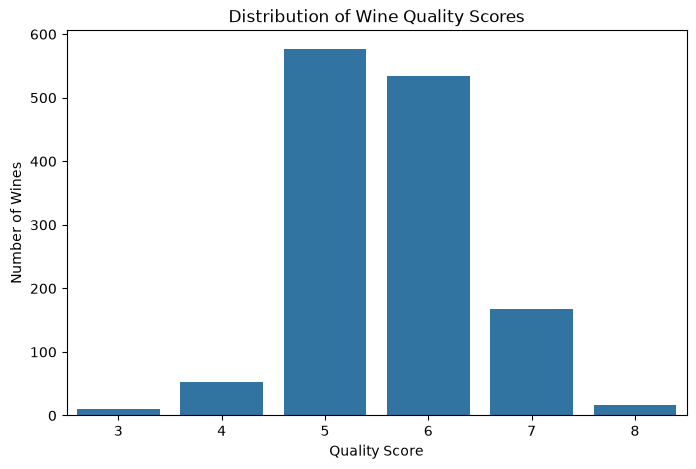

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="quality")

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")
plt.show()

The distribution of the wine quality scores shows that the classes are not evenly represented.

Most wines have quality scores around 5 and 6, while very low scores such as 3 and 4 and high scores such as 7 and 8 occur much less frequently.

Therefore, the dataset has a clear class imbalance. This imbalance may cause a classification model to favor the majority quality scores and perform less effectively on the underrepresented classes.

### Quality Percentages

In [ ]:
quality_percentage = df["quality"].value_counts(normalize=True).sort_index() * 100

print(quality_percentage.round(2))

quality
3     0.74
4     3.90
5    42.46
6    39.37
7    12.29
8     1.25
Name: proportion, dtype: float64


### EDA: Distribution of Chemical Features

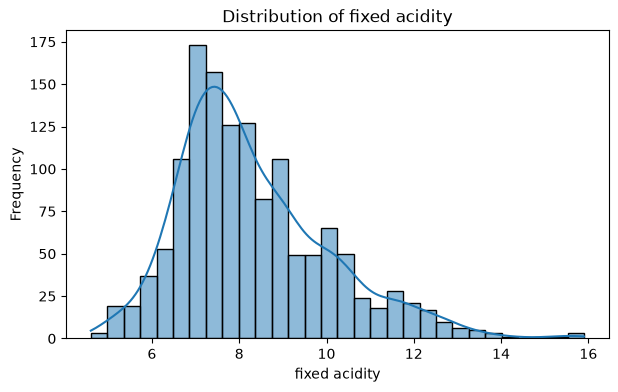

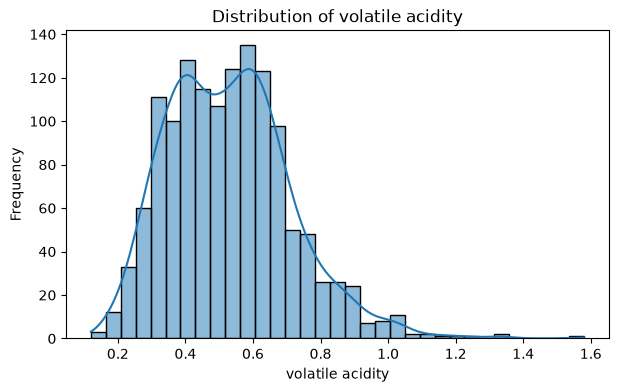

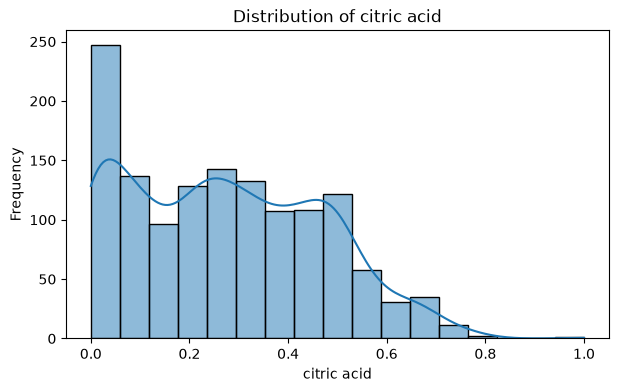

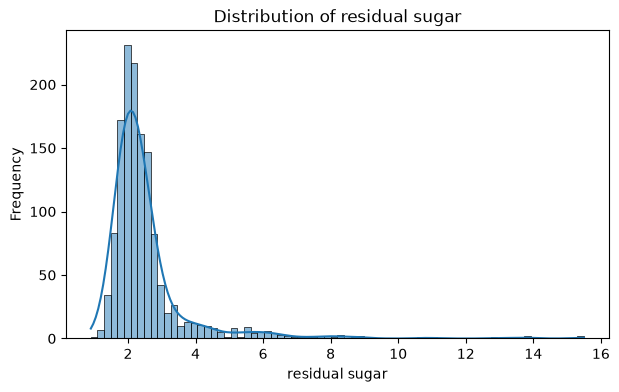

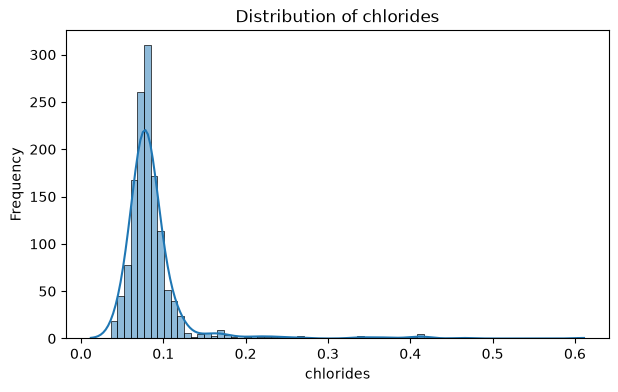

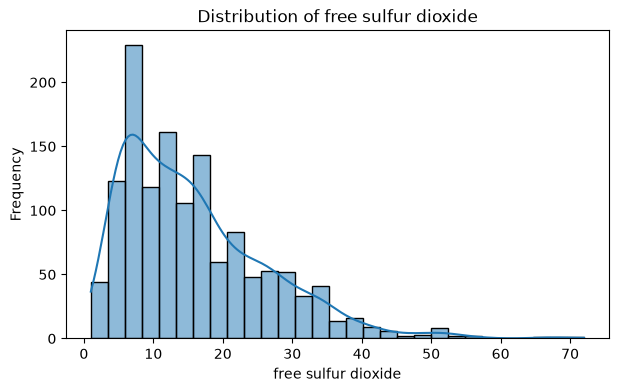

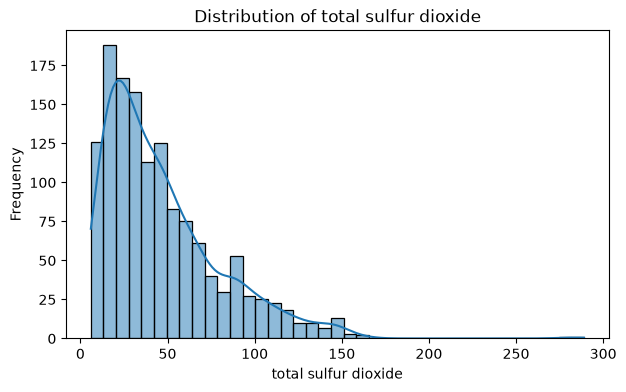

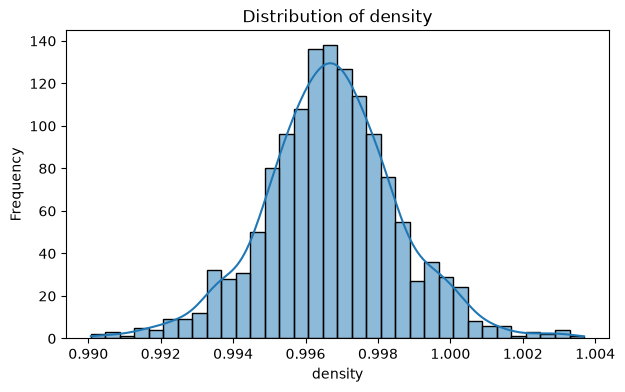

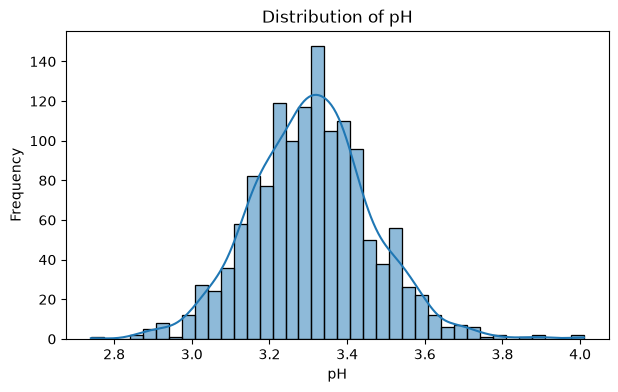

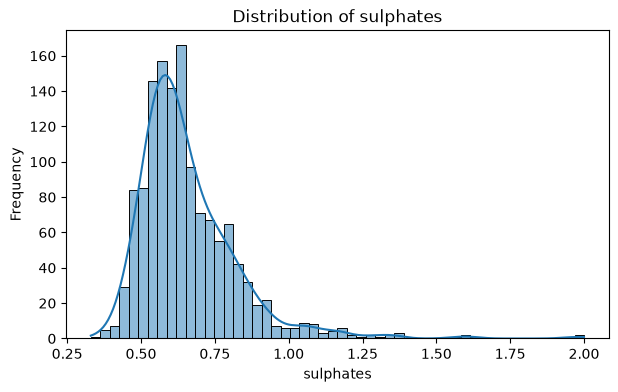

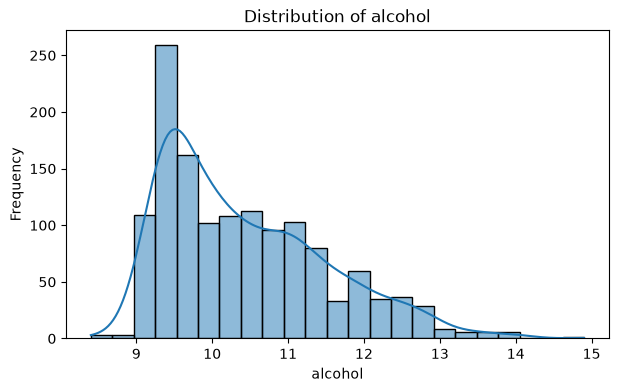

In [ ]:
features = df.drop(columns="quality").columns

for feature in features:
    plt.figure(figsize=(7, 4))
    
    sns.histplot(df[feature], kde=True)
    
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

The chemical features show different distributions and ranges. Several variables exhibit skewed distributions, while others are more concentrated around specific values. The differences in feature scales justify the use of standardization for models such as SGD and SVC.

### Correlation Heatmap

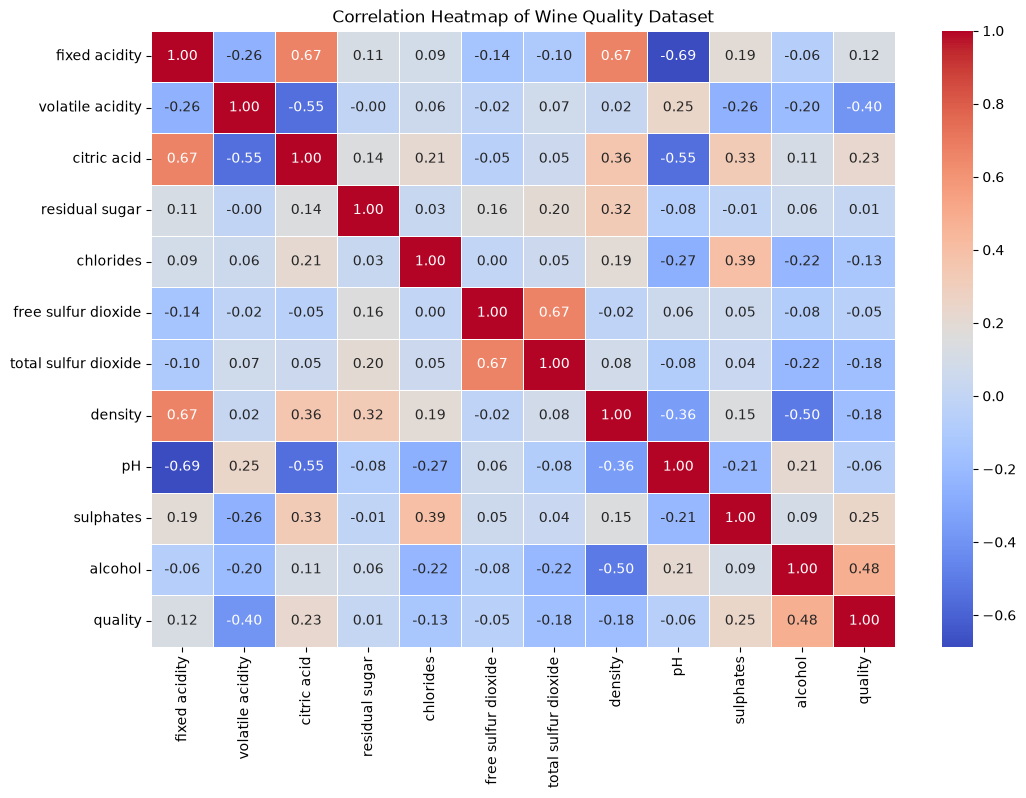

In [ ]:
plt.figure(figsize=(12, 8))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Wine Quality Dataset")
plt.show()

### Observation:
The correlation heatmap shows that **alcohol** (0.48) has the strongest positive correlation with wine **quality**, followed by **sulphates** (0.25) and **citric acid** (0.23), suggesting higher alcohol content and sulphate levels are associated with better quality wines. Conversely, **volatile acidity** (-0.40) shows the strongest negative correlation with quality, indicating that wines with higher volatile acidity tend to be rated lower. Among the features themselves, **fixed acidity** and **density** (0.67), **fixed acidity** and **citric acid** (0.67), and **free sulfur dioxide** and **total sulfur dioxide** (0.67) show strong positive correlations, while **fixed acidity** and **pH** (-0.69) show a strong negative correlation, reflecting expected chemical relationships (e.g., pH decreases as acidity increases). Overall, alcohol and volatile acidity emerge as the most influential features linearly related to wine quality, aligning with the feature importance results from the Random Forest model.

### Feature Engineeering
Creating new 3-class target

In [ ]:
def quality_category(quality):
    if quality <= 4:
        return "Low"
    elif quality <= 6:
        return "Medium"
    else:
        return "High"

df["quality_category"] = df["quality"].apply(quality_category)

In [ ]:
print(df["quality_category"].value_counts())

quality_category
Medium    1112
High       184
Low         63
Name: count, dtype: int64


After grouping the original scores, Medium-quality wines remain the dominant class, while Low- and High-quality wines contain fewer observations.
Therefore, class imbalance is still present after feature engineering.
To reduce the effect of this imbalance, stratified train-test splitting is used so that the proportions of the three quality categories are maintained in both training and testing datasets. Class balancing options are also used where appropriate during model training.

### Prepare X & y

In [ ]:
X = df.drop(columns=["quality", "quality_category"])

y = df["quality_category"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1359, 11)
Target shape: (1359,)


The original `quality` column and the newly created `quality_category` column are excluded from the input features.

The physicochemical measurements are used as independent variables (`X`), while `quality_category` is used as the target variable (`y`).

The original `quality` column must be removed because it was used to create the target categories. Keeping it as an input feature would cause target leakage and give the models direct access to information derived from the target.

### Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training set: (1087, 11)
Testing set: (272, 11)

Training class distribution:
quality_category
Medium    0.818767
High      0.135235
Low       0.045998
Name: proportion, dtype: float64

Testing class distribution:
quality_category
Medium    0.816176
High      0.136029
Low       0.047794
Name: proportion, dtype: float64


An 80/20 train-test split was used with stratification. Stratification preserves the approximate proportions of Low, Medium, and High quality wines in both the training and testing sets, reducing the risk of an unrepresentative test set.

### Feature & Scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Standardization was applied to the training and testing features using `StandardScaler`.

Scaling is particularly important for SGD and SVC because these algorithms can be sensitive to differences in feature magnitude.

The scaler was fitted only on the training data and then applied to the test data. This prevents information from the test set from influencing the training process and avoids data leakage.

### Random Forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy, 4))

Random Forest Accuracy: 0.8272


The Random Forest model achieved an accuracy of 0.8272 on the test dataset.

The model's classification report provides additional information about precision, recall, and F1-score for each quality category.

The confusion matrix is used to identify which quality categories are classified correctly and which categories are frequently confused with one another.

### Stochastic Gradient Descent Classifier (SDG)

The SGD Classifier is a linear classification algorithm that uses stochastic gradient descent for optimization.

Unlike Random Forest, SGD can be sensitive to feature scales, so the standardized features are used.

Class balancing is also applied because the wine quality categories are not equally represented.

In [ ]:
sgd_model = SGDClassifier(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

sgd_model.fit(X_train_scaled, y_train)

sgd_pred = sgd_model.predict(X_test_scaled)

sgd_accuracy = accuracy_score(y_test, sgd_pred)

print("SGD Accuracy:", round(sgd_accuracy, 4))

SGD Accuracy: 0.7426


### SGD Classifier Performance

 The SGD Classifier achieved an accuracy of **74.26%**, correctly classifying approximately three-fourths of the test samples. This indicates moderate predictive performance, although there is still room for improvement.


### Support Vector Classifier (SVC)

Support Vector Classification is a supervised learning algorithm that attempts to find decision boundaries that effectively separate different classes.

An RBF kernel is used because the relationship between physicochemical properties and wine quality may not be completely linear.

Standardized features are used because SVC is sensitive to the scale of the input variables.

In [ ]:
svc_model = SVC(
    kernel="rbf",
    class_weight="balanced",
    random_state=42
)

svc_model.fit(X_train_scaled, y_train)

svc_pred = svc_model.predict(X_test_scaled)

svc_accuracy = accuracy_score(y_test, svc_pred)

print("SVC Accuracy:", round(svc_accuracy, 4))

SVC Accuracy: 0.7096


### SVC Performance

The SVC model achieved an accuracy of 70.96%, correctly classifying approximately 71% of the test samples. Its performance was slightly lower than the SGD Classifier, indicating that SGD performed better on this dataset based on accuracy alone.

### Classification Reports

### Model Evaluation

The three models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

Accuracy measures the overall proportion of correct predictions.

Precision measures how many observations predicted as a particular class actually belong to that class.

Recall measures how many observations belonging to a class were correctly identified.

F1-score combines precision and recall and is particularly useful when class distributions are imbalanced.

Because the wine quality categories are imbalanced, macro F1-score is considered alongside accuracy when comparing the models.

In [ ]:
print("===== RANDOM FOREST =====")
print(classification_report(y_test, rf_pred))

print("===== SGD CLASSIFIER =====")
print(classification_report(y_test, sgd_pred))

print("===== SVC =====")
print(classification_report(y_test, svc_pred))

===== RANDOM FOREST =====
              precision    recall  f1-score   support

        High       0.51      0.70      0.59        37
         Low       0.60      0.46      0.52        13
      Medium       0.91      0.87      0.89       222

    accuracy                           0.83       272
   macro avg       0.67      0.68      0.67       272
weighted avg       0.84      0.83      0.83       272

===== SGD CLASSIFIER =====
              precision    recall  f1-score   support

        High       0.42      0.68      0.52        37
         Low       0.23      0.46      0.31        13
      Medium       0.92      0.77      0.84       222

    accuracy                           0.74       272
   macro avg       0.52      0.64      0.55       272
weighted avg       0.82      0.74      0.77       272

===== SVC =====
              precision    recall  f1-score   support

        High       0.45      0.81      0.58        37
         Low       0.21      0.69      0.33        13
      

### Model Comparison:
Random Forest performed best with an accuracy of 83% and a weighted F1-score of 0.83. It significantly outperformed the SGD Classifier (74%) and SVC (71%). Random Forest showed particularly strong performance in predicting the Medium class, while predictions for the High and Low classes were comparatively weaker. Since the dataset is imbalanced, with the Medium class representing most of the samples, macro F1-score is also important when evaluating overall class-wise performance.

### Confusion Matrix: Random Forest

The confusion matrix shows the actual quality categories against the categories predicted by the Random Forest model.

The diagonal values represent correctly classified wines, while the off-diagonal values represent incorrect predictions.

Most classification errors are expected to occur between neighboring quality categories because wines with similar physicochemical properties can have similar quality levels.

The matrix should be examined together with the classification report to determine whether the model performs adequately on the minority classes.

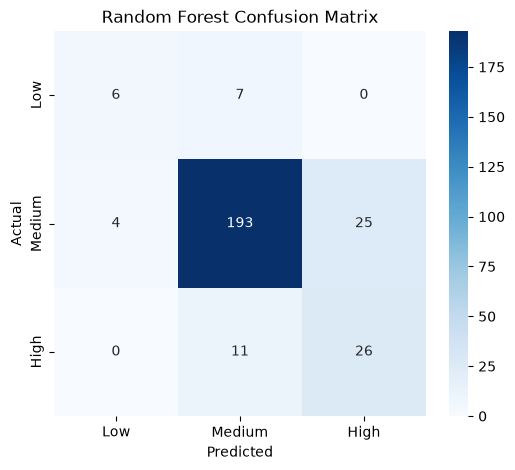

In [ ]:
cm_rf = confusion_matrix(
    y_test,
    rf_pred,
    labels=["Low", "Medium", "High"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### Observation:
 The Random Forest model correctly classified most of the samples, particularly those belonging to the Medium class. However, some Low and High samples were misclassified as Medium. The model performed well overall, but the class imbalance may have contributed to its tendency to predict the majority Medium class. classes.

### Confusion Matrix: SGD

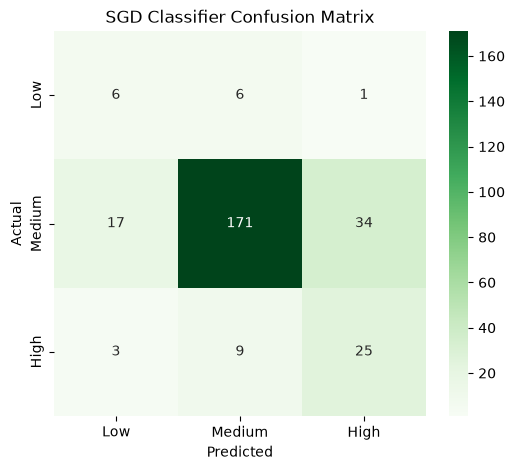

In [ ]:
cm_sgd = confusion_matrix(
    y_test,
    sgd_pred,
    labels=["Low", "Medium", "High"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_sgd,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("SGD Classifier Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### SGD Classifier
The SGD classifier correctly classified most of the samples, particularly those belonging to the Medium class. However, several Low and High samples were misclassified as Medium, and vice versa — 17 Low samples were predicted as Medium, and 34 Medium samples were predicted as High. The model performed reasonably well overall, but the class imbalance likely contributed to its tendency to favor predicting the majority Medium class, resulting in weaker recall and precision for the Low and High classes.

### ConfusionMatrix: SVC

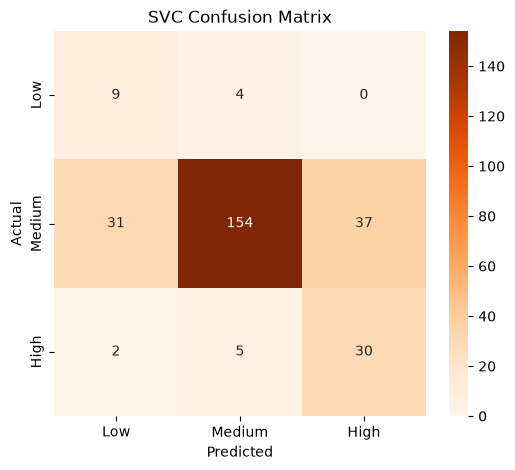

In [ ]:
cm_svc = confusion_matrix(
    y_test,
    svc_pred,
    labels=["Low", "Medium", "High"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svc,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("SVC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Observation:
The SVC model correctly classified most of the samples, particularly those belonging to the Medium class. However, several Low and Medium samples were misclassified as Medium and High respectively 31 Medium samples were predicted as Low, and 37 Medium samples were predicted as High. The model performed reasonably well overall, especially for the High class, but the class imbalance likely contributed to it's tendency to favor predicting the majority Medium class, resulting in weaker precision for the Low and High classes.

### Random Forest Feature Importance

Random Forest provides feature importance values that indicate the relative contribution of each physicochemical property to the model's predictions.

Features with higher importance have a greater influence on the classification decisions of the Random Forest model.

This analysis helps identify which chemical characteristics are most useful for predicting wine quality.

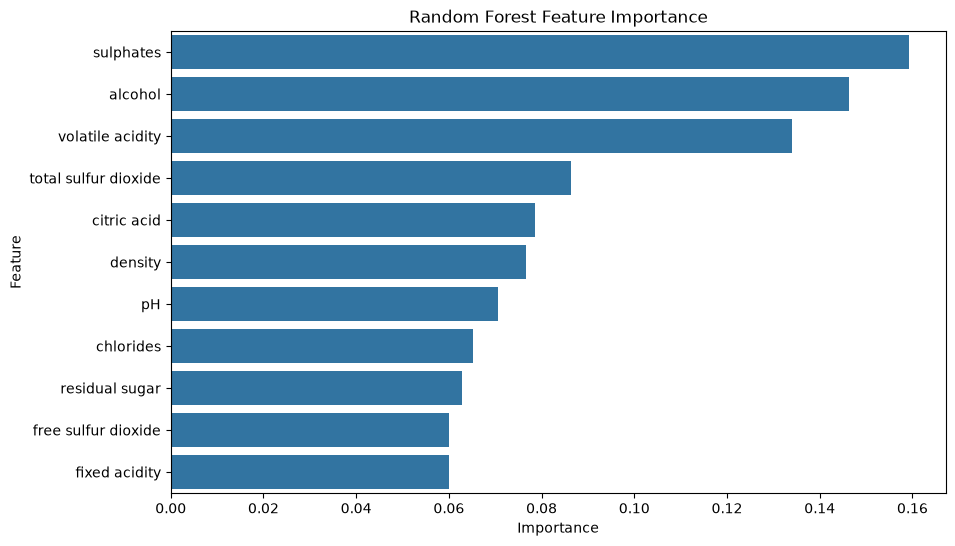

In [ ]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The feature importance chart shows that **sulphates** has the highest importance in the Random Forest model, followed by **alchohol** and **volatile acidity**.

This indicates that these physicochemical properties contribute more strongly to the model's classification decisions than the lower-ranked features.

However, feature importance represents the model's predictive behavior and should not be interpreted as proof that a particular chemical property directly causes higher or lower wine quality.

### Top Features

In [ ]:
print("Feature Importance:")
display(feature_importance.to_frame("Importance"))

Feature Importance:


,Importance
sulphates,0.159221
alcohol,0.146267
volatile acidity,0.134030
total sulfur dioxide,0.086430
citric acid,0.078679
density,0.076726
pH,0.070503
chlorides,0.065212
residual sugar,0.062857
free sulfur dioxide,0.060078


The feature importance analysis indicates which physicochemical properties contribute most to the Random Forest's classification decisions. Features with higher importance have a greater influence on the model's predictions. Sulphates is expected to be among the more influential variables, although the final ranking should be interpreted from the actual model output.

### Model Performance Comparison

The three classification models are compared using accuracy, weighted F1-score, and macro F1-score.

Accuracy provides an overall measure of correct predictions, while macro F1-score gives equal importance to all three quality categories.

Macro F1-score is particularly useful in this project because the quality classes are imbalanced.

Therefore, the final model selection should consider both overall accuracy and balanced performance across the Low, Medium, and High categories.


In [ ]:
from sklearn.metrics import f1_score

comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SGD Classifier",
        "SVC"
    ],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, sgd_pred),
        accuracy_score(y_test, svc_pred)
    ],
    "Weighted F1": [
        f1_score(y_test, rf_pred, average="weighted"),
        f1_score(y_test, sgd_pred, average="weighted"),
        f1_score(y_test, svc_pred, average="weighted")
    ],
    "Macro F1": [
        f1_score(y_test, rf_pred, average="macro"),
        f1_score(y_test, sgd_pred, average="macro"),
        f1_score(y_test, svc_pred, average="macro")
    ]
})

comparison = comparison.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

comparison

,Model,Accuracy,Weighted F1,Macro F1
0,Random Forest,0.827206,0.832902,0.668034
1,SVC,0.709559,0.747061,0.568065
2,SGD Classifier,0.742647,0.768972,0.553797


### Observation:
Among the three models, **Random Forest** achieved the best overall performance, with the highest accuracy (82.7%), weighted F1 (0.833), and macro F1 (0.668), indicating it handled both the majority (Medium) class and the minority (Low, High) classes better than the other models. **SGD Classifier** slightly outperformed **SVC** in accuracy (74.3% vs. 71.0%) and weighted F1 (0.769 vs. 0.747), but **SVC** had a marginally higher macro F1 (0.568 vs. 0.554), suggesting a somewhat more balanced performance across classes despite its lower overall accuracy. Overall, Random Forest is the most robust model, while SVC and SGD Classifier show comparable but weaker performance, particularly in classifying the minority Low and High classes.

### Comparison Visualization

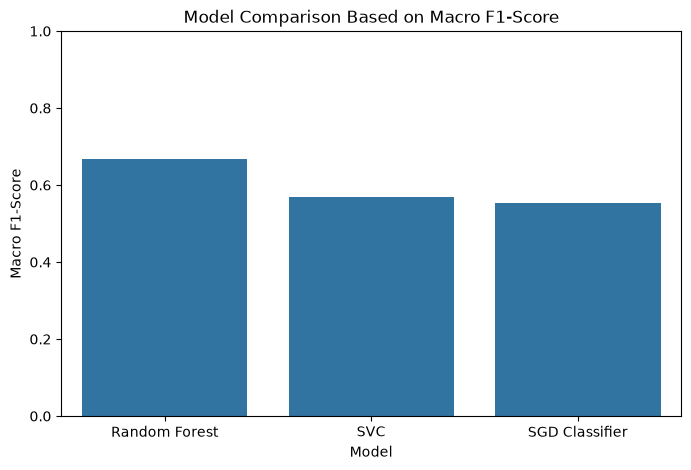

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Macro F1"
)

plt.title("Model Comparison Based on Macro F1-Score")
plt.xlabel("Model")
plt.ylabel("Macro F1-Score")
plt.ylim(0, 1)
plt.show()

The comparison chart summarizes the macro F1-scores of the three classification algorithms.

A higher macro F1-score indicates better and more balanced performance across the Low, Medium, and High quality categories.

The Random Forest model with the highest macro F1-score is considered the strongest performer based on balanced classification performance.

### Conclusion

This project developed and compared three machine learning classification models for predicting wine quality from physicochemical properties.

The original quality scores were converted into three categories: Low, Medium, and High. This reduced the problem caused by very small individual quality-score classes while retaining meaningful quality groups.

Exploratory data analysis showed that the wine quality classes are imbalanced, with Medium-quality wines being considerably more common than Low- and High-quality wines. Because of this imbalance, stratified train-test splitting and class balancing techniques were used, and model performance was evaluated using accuracy as well as precision, recall, F1-score, and confusion matrices.

The three models—Random Forest, SGD Classifier, and SVC—showed different levels of predictive performance.

Based on the experimental results, **Random Forest** model achieved the strongest overall performance, with an accuracy of 82.7% a macro F1-score of **0.668034**.

Therefore, **Random Forest Model** is the most suitable model among the three for this project because it provides the best balance between overall predictive accuracy and performance across the different wine quality categories.

The Random Forest feature importance analysis also provided insight into which physicochemical properties were most useful for prediction.

However, the model should be further validated using cross-validation and additional wine samples before being considered for real-world deployment.